## Outlier Detection and Data Quality

Extreme values in price, price per square footage, close to list ratio, or days on market can distort market
averages and trends. You will implement a statistical method to identify and remove these records.

In [1]:
import pandas as pd
from pathlib import Path

REPORTS_DIR = Path(r"C:\Users\khush\Desktop\IDX-Exchange\Reports")

sold = pd.read_csv(REPORTS_DIR / "sold_with_districts.csv", low_memory=False)

print(f"Sold: {sold.shape[0]:,} rows x {sold.shape[1]} columns")

Sold: 448,253 rows x 75 columns


In [2]:
# Baseline distribution before outlier flagging
numeric_cols = ['ClosePrice', 'LivingArea', 'DaysOnMarket']

print("=== Baseline Distribution (Before Outlier Flagging) ===")
print(sold[numeric_cols].describe(percentiles=[.05, .25, .5, .75, .95]))

=== Baseline Distribution (Before Outlier Flagging) ===
         ClosePrice    LivingArea   DaysOnMarket
count  4.482490e+05  4.479990e+05  448253.000000
mean   1.183711e+06  1.904183e+03      37.326675
std    5.562462e+06  2.544772e+04      53.628852
min    0.000000e+00  0.000000e+00    -288.000000
5%     3.400000e+05  8.400000e+02       1.000000
25%    5.750000e+05  1.248000e+03       8.000000
50%    8.250000e+05  1.646000e+03      18.000000
75%    1.300000e+06  2.224000e+03      48.000000
95%    2.854717e+06  3.563100e+03     132.000000
max    9.895000e+08  1.702132e+07   12430.000000


Key numbers to remember for comparison later:

Median ClosePrice: $825,000

Median LivingArea: 1,646 sqft

Median DaysOnMarket: 18 days

In [3]:
# IQR Outlier Detection
def add_iqr_flag(df, column, multiplier=1.5):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - multiplier * IQR
    upper = Q3 + multiplier * IQR
    flag_col = f"{column.lower()}_outlier_flag"
    df[flag_col] = (df[column] < lower) | (df[column] > upper)
    print(f"{column}: lower={lower:,.0f}, upper={upper:,.0f}, flagged={df[flag_col].sum():,} ({df[flag_col].mean()*100:.1f}%)")
    return df

sold = add_iqr_flag(sold, 'ClosePrice')
sold = add_iqr_flag(sold, 'LivingArea')
sold = add_iqr_flag(sold, 'DaysOnMarket')

ClosePrice: lower=-512,500, upper=2,387,500, flagged=33,528 (7.5%)
LivingArea: lower=-216, upper=3,688, flagged=19,578 (4.4%)
DaysOnMarket: lower=-52, upper=108, flagged=34,235 (7.6%)


In [4]:
# Compare with 3.0x multiplier
print("=== Comparison: 1.5x vs 3.0x IQR multiplier ===\n")

for col in ['ClosePrice', 'LivingArea', 'DaysOnMarket']:
    Q1 = sold[col].quantile(0.25)
    Q3 = sold[col].quantile(0.75)
    IQR = Q3 - Q1
    
    for multiplier in [1.5, 3.0]:
        lower = Q1 - multiplier * IQR
        upper = Q3 + multiplier * IQR
        flagged = ((sold[col] < lower) | (sold[col] > upper)).sum()
        pct = flagged / len(sold) * 100
        print(f"{col} ({multiplier}x): upper={upper:,.0f}, flagged={flagged:,} ({pct:.1f}%)")
    print()

=== Comparison: 1.5x vs 3.0x IQR multiplier ===

ClosePrice (1.5x): upper=2,387,500, flagged=33,528 (7.5%)
ClosePrice (3.0x): upper=3,475,000, flagged=14,451 (3.2%)

LivingArea (1.5x): upper=3,688, flagged=19,578 (4.4%)
LivingArea (3.0x): upper=5,152, flagged=4,931 (1.1%)

DaysOnMarket (1.5x): upper=108, flagged=34,235 (7.6%)
DaysOnMarket (3.0x): upper=168, flagged=11,941 (2.7%)



ging w/ 3.0 x multiplier since it is less agressive to cutting out luxury homes

In [5]:
# Redo IQR flags with 3.0x multiplier
sold = add_iqr_flag(sold, 'ClosePrice', multiplier=3.0)
sold = add_iqr_flag(sold, 'LivingArea', multiplier=3.0)
sold = add_iqr_flag(sold, 'DaysOnMarket', multiplier=3.0)

# Combined flag — True if ANY field is flagged
sold['iqr_outlier_any_flag'] = (
    sold['closeprice_outlier_flag'] |
    sold['livingarea_outlier_flag'] |
    sold['daysonmarket_outlier_flag']
)

print(f"Records flagged by at least one IQR flag: {sold['iqr_outlier_any_flag'].sum():,} ({sold['iqr_outlier_any_flag'].mean()*100:.1f}%)")

ClosePrice: lower=-1,600,000, upper=3,475,000, flagged=14,451 (3.2%)
LivingArea: lower=-1,680, upper=5,152, flagged=4,931 (1.1%)
DaysOnMarket: lower=-112, upper=168, flagged=11,941 (2.7%)
Records flagged by at least one IQR flag: 26,695 (6.0%)


In [6]:
# Save full flagged dataset (all records with flag columns)
sold.to_csv(REPORTS_DIR / "sold_flagged.csv", index=False)
print(f"Full flagged dataset saved: {sold.shape[0]:,} rows x {sold.shape[1]} columns")

# Save clean filtered dataset (only non-flagged records)
sold_filtered = sold[~sold['iqr_outlier_any_flag']]
sold_filtered.to_csv(REPORTS_DIR / "sold_filtered.csv", index=False)
print(f"Clean filtered dataset saved: {sold_filtered.shape[0]:,} rows x {sold_filtered.shape[1]} columns")

# Written comparison
print("\n=== Before vs After Filtering ===")
print(f"{'Metric':<25} {'Before':>15} {'After':>15} {'Change':>10}")
print("-" * 65)
print(f"{'Row count':<25} {len(sold):>15,} {len(sold_filtered):>15,} {len(sold_filtered)-len(sold):>10,}")
print(f"{'Median ClosePrice':<25} ${sold['ClosePrice'].median():>14,.0f} ${sold_filtered['ClosePrice'].median():>14,.0f} ${sold_filtered['ClosePrice'].median()-sold['ClosePrice'].median():>9,.0f}")
print(f"{'Median LivingArea':<25} {sold['LivingArea'].median():>14,.0f} {sold_filtered['LivingArea'].median():>14,.0f} {sold_filtered['LivingArea'].median()-sold['LivingArea'].median():>10,.0f}")
print(f"{'Median DaysOnMarket':<25} {sold['DaysOnMarket'].median():>14,.0f} {sold_filtered['DaysOnMarket'].median():>14,.0f} {sold_filtered['DaysOnMarket'].median()-sold['DaysOnMarket'].median():>10,.0f}")
print(f"{'Mean ClosePrice':<25} ${sold['ClosePrice'].mean():>14,.0f} ${sold_filtered['ClosePrice'].mean():>14,.0f} ${sold_filtered['ClosePrice'].mean()-sold['ClosePrice'].mean():>9,.0f}")

Full flagged dataset saved: 448,253 rows x 79 columns
Clean filtered dataset saved: 421,558 rows x 79 columns

=== Before vs After Filtering ===
Metric                             Before           After     Change
-----------------------------------------------------------------
Row count                         448,253         421,558    -26,695
Median ClosePrice         $       825,000 $       808,000 $  -17,000
Median LivingArea                  1,646          1,614        -32
Median DaysOnMarket                   18             17         -1
Mean ClosePrice           $     1,183,711 $       984,326 $ -199,385


### Week 7 – Outlier Detection Summary

Interquartile Range (IQR) with 3.0x multiplier
A 3.0x multiplier was chosen over the textbook 1.5x because California real estate 
is heavily right-skewed. The 1.5x multiplier flagged 7.5% of ClosePrice records with 
an upper bound of $2.4M — too low for legitimate luxury markets like San Mateo ($1.7M median) 
and Santa Clara ($1.6M median). The 3.0x multiplier sets a more appropriate $3.475M upper 
bound and flags only 3.2% of records.

**IQR Bounds (3.0x multiplier):**
- ClosePrice: upper = $3,475,000 — flagged 14,451 records (3.2%)
- LivingArea: upper = 5,152 sqft — flagged 4,931 records (1.1%)
- DaysOnMarket: upper = 168 days — flagged 11,941 records (2.7%)
- Combined (any flag): 26,695 records flagged (6.0%)

**Before vs After Filtering:**

| Metric | Before | After | Change |
|---|---|---|---|
| Row count | 448,253 | 421,558 | -26,695 |
| Median ClosePrice | $825,000 | $808,000 | -$17,000 |
| Median LivingArea | 1,646 sqft | 1,614 sqft | -32 sqft |
| Median DaysOnMarket | 18 days | 17 days | -1 day |
| Mean ClosePrice | $1,183,711 | $984,326 | -$199,385 |

**Key Takeaway:**
Removing the 6% flagged records moved the **median close price by only 2%** ($17k) 
but the **mean by 17%** ($199k). This confirms that medians resist outliers and 
justifies their use throughout this project's market analysis. The filtered dataset 
(421,558 rows) will be used for Tableau dashboards where typical market behavior 
is the focus, while the full flagged dataset (448,253 rows) is preserved for 
complete market analysis.

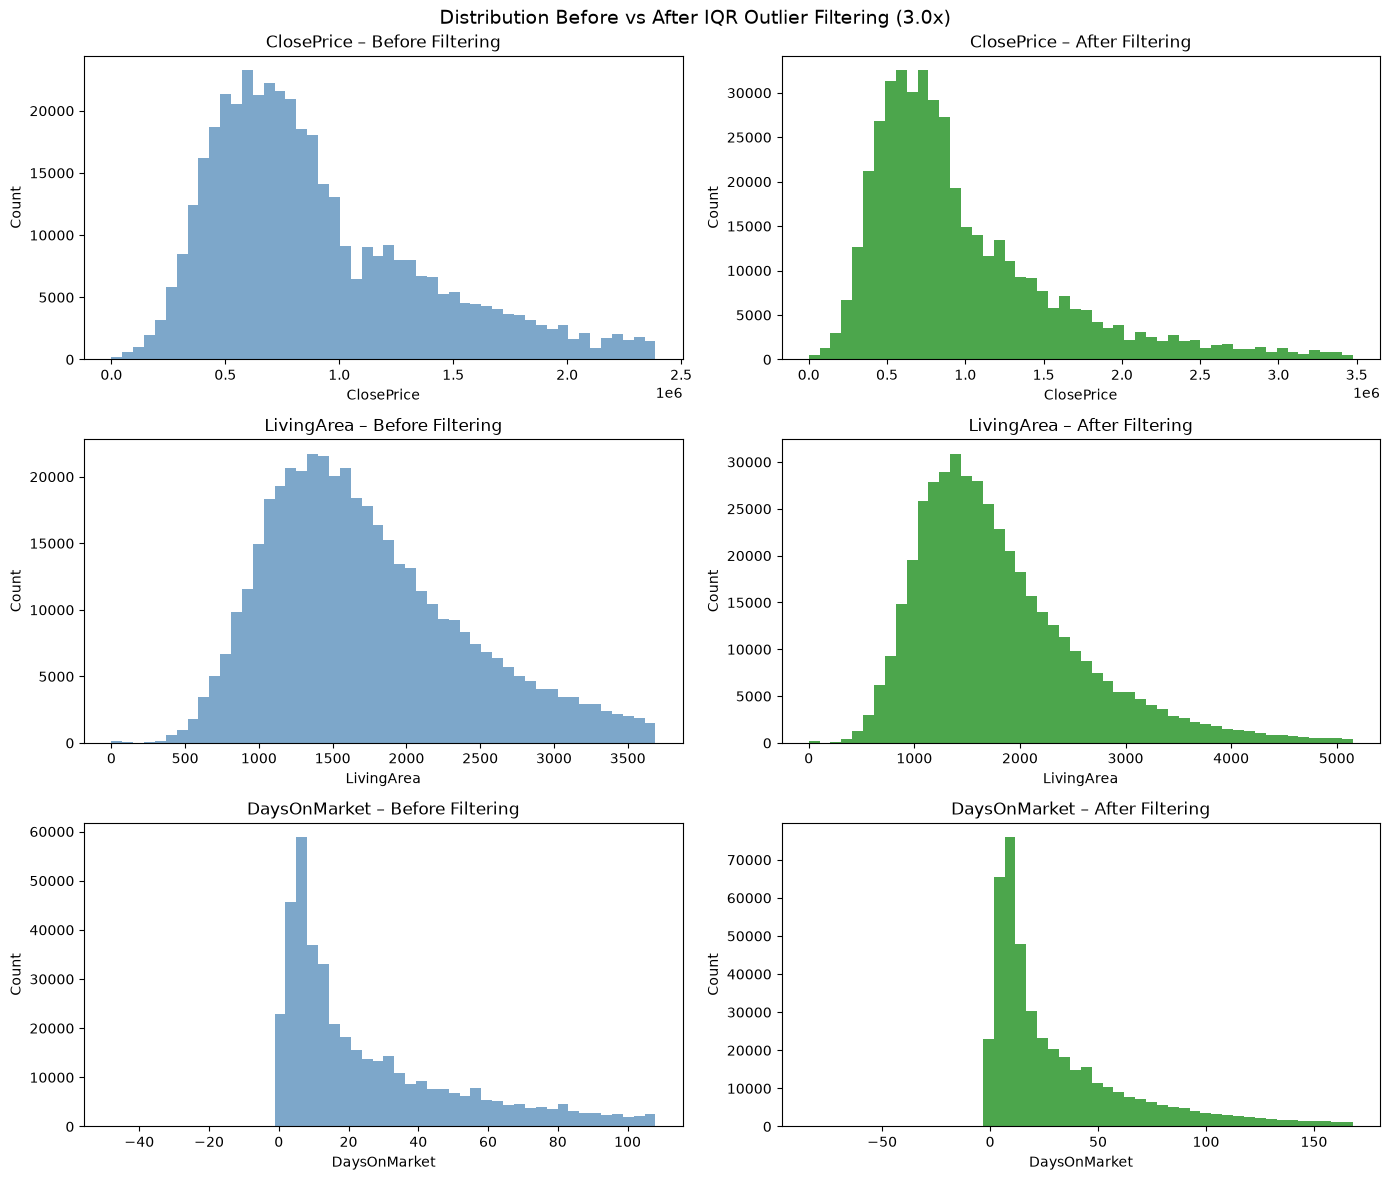

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 2, figsize=(14, 12))

for i, col in enumerate(['ClosePrice', 'LivingArea', 'DaysOnMarket']):
    flag_col = f"{col.lower()}_outlier_flag"
    
    # Before (full dataset, outliers removed for readability using IQR 1.5x)
    series_before = sold[col].dropna()
    q1, q3 = series_before.quantile(0.25), series_before.quantile(0.75)
    iqr = q3 - q1
    before_filtered = series_before[(series_before >= q1 - 1.5*iqr) & (series_before <= q3 + 1.5*iqr)]
    
    # After (only non-flagged records)
    series_after = sold[~sold[flag_col]][col].dropna()
    
    # Histogram
    axes[i, 0].hist(before_filtered, bins=50, color='steelblue', alpha=0.7)
    axes[i, 0].set_title(f'{col} – Before Filtering')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Count')
    
    # After histogram
    axes[i, 1].hist(series_after, bins=50, color='green', alpha=0.7)
    axes[i, 1].set_title(f'{col} – After Filtering')
    axes[i, 1].set_xlabel(col)
    axes[i, 1].set_ylabel('Count')

plt.suptitle('Distribution Before vs After IQR Outlier Filtering (3.0x)', fontsize=14)
plt.tight_layout()
plt.show()


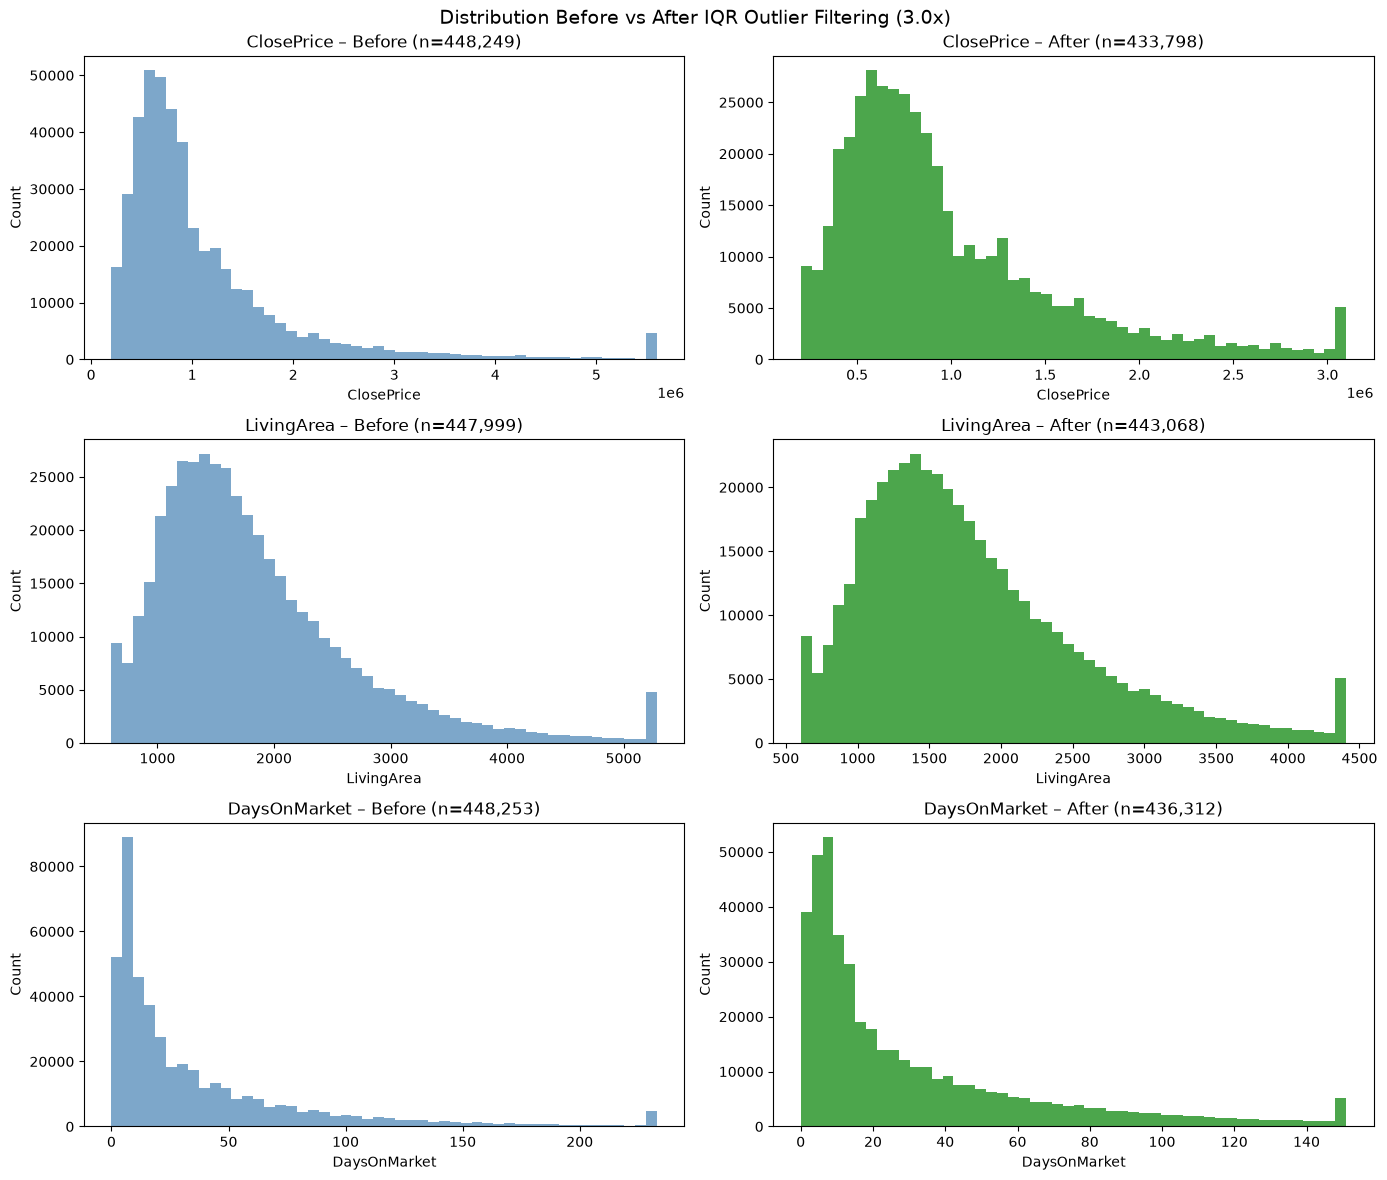

In [8]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

for i, col in enumerate(['ClosePrice', 'LivingArea', 'DaysOnMarket']):
    flag_col = f"{col.lower()}_outlier_flag"
    
    before = sold[col].dropna()
    after = sold[~sold[flag_col]][col].dropna()
    
    # Before
    axes[i, 0].hist(before.clip(before.quantile(0.01), before.quantile(0.99)), bins=50, color='steelblue', alpha=0.7)
    axes[i, 0].set_title(f'{col} – Before (n={len(before):,})')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Count')
    
    # After
    axes[i, 1].hist(after.clip(after.quantile(0.01), after.quantile(0.99)), bins=50, color='green', alpha=0.7)
    axes[i, 1].set_title(f'{col} – After (n={len(after):,})')
    axes[i, 1].set_xlabel(col)
    axes[i, 1].set_ylabel('Count')

plt.suptitle('Distribution Before vs After IQR Outlier Filtering (3.0x)', fontsize=14)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(3, 2, figsize=(14, 12))

for i, col in enumerate(['ClosePrice', 'LivingArea', 'DaysOnMarket']):
    flag_col = f"{col.lower()}_outlier_flag"
    
    before = sold[col].dropna()
    after = sold[~sold[flag_col]][col].dropna()
    
    # Before
    axes[i, 0].hist(before.clip(before.quantile(0.01), before.quantile(0.99)), bins=50, color='steelblue', alpha=0.7)
    axes[i, 0].set_title(f'{col} – Before (n={len(before):,})')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Count')
    
    # After
    axes[i, 1].hist(after.clip(after.quantile(0.01), after.quantile(0.99)), bins=50, color='green', alpha=0.7)
    axes[i, 1].set_title(f'{col} – After (n={len(after):,})')
    axes[i, 1].set_xlabel(col)
    axes[i, 1].set_ylabel('Count')

plt.suptitle('Distribution Before vs After IQR Outlier Filtering (3.0x)', fontsize=14)
plt.tight_layout()
plt.show()